In [147]:
import pandas as pd
df_peso = pd.read_stata(r'C:\Users\vimed\Downloads\banco_ISA_Vinicius (1).dta')

df = pd.read_csv(r'C:\Users\vimed\Downloads\Data_Set_para_Contrafactuais.csv')

df = df.merge(df_peso,right_on='id_original', left_on='id', how='inner')

In [148]:
import pandas as pd
import statsmodels.api as sm

df = df.copy()
# Limpeza das Colunas
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

 # Calculo das diferenças entre atividade fisica e Kilometragens
df['delta_minutos'] = pd.to_numeric(df['aftotal2'], errors='coerce') - \
                      pd.to_numeric(df['aftotal1'], errors='coerce')
df['delta_km'] = pd.to_numeric(df['km2020'], errors='coerce') - \
                 pd.to_numeric(df['km2015'], errors='coerce')

# Calculo das diferenças
df['delta_minutos'] = df['delta_minutos'].astype(float)
df['delta_km'] = df['delta_km'].astype(float)



resumo = [] #armazenar os resultados resumidos por categorias

anos = 6 #anos  analisados

# Loop por categoria
for cat, grupo in df.groupby('categorias'):
    if len(grupo) > 2: #ter pelos menos dois integrantes por cada categoria
        y = grupo['delta_minutos'].astype(float).values # variavel dependente
        X = sm.add_constant(grupo['delta_km'].astype(float).values) #variavel independente

        model = sm.OLS(y, X).fit()

        beta_total = model.params[1]   #coeficiente da variavel independente
        intercepto = model.params[0]   #intercepeto
        r2 = model.rsquared  #coeficente de r^2
        pval = model.pvalues[1] # coeficiente do p-valor

        # beta médio anual (minutos por semana / ano)
        beta_anual = beta_total / anos

        # contrafactuais
        cf1 = intercepto  
        cf2a = grupo['aftotal1'].mean()
        X_cf2b = sm.add_constant(grupo['km2015'].astype(float).values)
        cf2b = model.predict(X_cf2b).mean()
# armazenamento dos resultados em formato de listagem
        resumo.append({
            "Categoria": cat,
            "Aumento médio anual (min/km)": round(beta_anual, 3),
            "Intercepto (sem expansão)": round(intercepto, 2),
            "R²": round(r2, 3),
            "p-valor": round(pval, 4),
            "N": len(grupo),
        })
# transformacao em dataframe o ordenação 
df_resumo = pd.DataFrame(resumo).sort_values(
    "Aumento médio anual (min/km)", ascending=False
)






In [149]:
import pandas as pd
import numpy as np
#
col_beta = "Aumento médio anual (min/km)"

df_filtrado = df_resumo[df_resumo[col_beta] > 0].copy()

df_filtrado[col_beta + " - Quartil"] = pd.qcut(
    df_filtrado[col_beta],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

media_q4 = df_filtrado[col_beta].quantile(0.75)

df_resumo[col_beta] = df_resumo[col_beta].apply(lambda x: media_q4 if x <= 0 else x)

df_resumo['percentil'] = df_resumo[col_beta].rank(pct=True)
df_resumo[col_beta + " - Quartil"] = df_resumo['percentil'].apply(
    lambda x: 'Q1' if x <= 0.25 else 'Q2' if x <= 0.50 else 'Q3' if x <= 0.75 else 'Q4'
)
df_resumo.drop('percentil', axis=1, inplace=True)

df_resumo


,Categoria,Aumento médio anual (min/km),Intercepto (sem expansão),R²,p-valor,N,Aumento médio anual (min/km) - Quartil
41,M|Adultos|Branca|Renda Baixa|Até Ensino Fundam...,2708.032,-1275.00,0.697,0.3708,3,Q4
47,M|Adultos|Outros|Renda Alta|Até Ensino Fundame...,1626.795,-863.33,0.775,0.1198,4,Q4
69,M|Jovens e Adolescentes|Branca|Renda Baixa|Ens...,1492.456,-1403.23,0.176,0.4816,5,Q4
37,F|Jovens e Adolescentes|Outros|Renda Média|Até...,1116.211,-52.50,0.060,0.6904,5,Q4
42,M|Adultos|Branca|Renda Baixa|Ensino Médio e Su...,604.616,437.32,0.079,0.5888,6,Q4
...,...,...,...,...,...,...,...
75,M|Jovens e Adolescentes|Outros|Renda Média-Bai...,221.859,1931.00,0.079,0.5886,6,Q3
5,F|Adultos|Branca|Renda Média|Até Ensino Fundam...,221.859,1311.32,0.401,0.1771,6,Q3
65,M|Idosos|Outros|Renda Não Declarada|Até Ensino...,221.859,3449.38,0.191,0.5633,4,Q3
50,M|Adultos|Outros|Renda Média|Até Ensino Fundam...,221.859,1385.09,0.059,0.5283,9,Q3


In [150]:
df_resumo = df_resumo.rename(columns={'Categoria': 'Categorias'})
df_resumo

,Categorias,Aumento médio anual (min/km),Intercepto (sem expansão),R²,p-valor,N,Aumento médio anual (min/km) - Quartil
41,M|Adultos|Branca|Renda Baixa|Até Ensino Fundam...,2708.032,-1275.00,0.697,0.3708,3,Q4
47,M|Adultos|Outros|Renda Alta|Até Ensino Fundame...,1626.795,-863.33,0.775,0.1198,4,Q4
69,M|Jovens e Adolescentes|Branca|Renda Baixa|Ens...,1492.456,-1403.23,0.176,0.4816,5,Q4
37,F|Jovens e Adolescentes|Outros|Renda Média|Até...,1116.211,-52.50,0.060,0.6904,5,Q4
42,M|Adultos|Branca|Renda Baixa|Ensino Médio e Su...,604.616,437.32,0.079,0.5888,6,Q4
...,...,...,...,...,...,...,...
75,M|Jovens e Adolescentes|Outros|Renda Média-Bai...,221.859,1931.00,0.079,0.5886,6,Q3
5,F|Adultos|Branca|Renda Média|Até Ensino Fundam...,221.859,1311.32,0.401,0.1771,6,Q3
65,M|Idosos|Outros|Renda Não Declarada|Até Ensino...,221.859,3449.38,0.191,0.5633,4,Q3
50,M|Adultos|Outros|Renda Média|Até Ensino Fundam...,221.859,1385.09,0.059,0.5283,9,Q3


# Carregamento Novamente do Banco de Dados

In [151]:
import pandas as pd
#subida novamente do dataset
df_peso = pd.read_stata(r'C:\Users\vimed\Downloads\banco_ISA_Vinicius (1).dta')
df = pd.read_csv(r'C:\Users\vimed\Downloads\Data_Set_para_Contrafactuais.csv')
#Merge dos dataset
df = df.merge(df_peso,right_on='id_original', left_on='id', how='inner')
df =df.copy()

In [152]:
import pandas as pd
#conversao de datas de nascimento
def remover_datas_invalidas(df, coluna="datanasc"):
#se a data nao conseguir converter  para o modelo do pandas pandas, converter para NAT
    df[coluna] = pd.to_datetime(df[coluna], dayfirst=True, errors='coerce')
#elimina linhas com nat
    df = df.dropna(subset=[coluna]).reset_index(drop=True)
    return df
#aplicacao da funcao
df = remover_datas_invalidas(df)


In [153]:
df_resultado = df_resumo.copy()

In [154]:
import pandas as pd
# periodo de anos analisados
anos = range(2015, 2021)
#categorias de atividade fisica para classificacao
categorias_atividade = ["Sedentário", "Pouco Ativo", "Moderadamente Ativo", "Ativo", "Extremamente Ativo"]
#método de mapeamento para  caracterixacao de fator de atividade fisica mediante a classificacao supracitada
mapa_fatores = {"Sedentário": 1.2, "Pouco Ativo": 1.35, "Moderadamente Ativo": 1.55, "Ativo": 1.72, "Extremamente Ativo": 1.9}

# Classificação em nivel de atividade fisica de acordo com os minutos
def classificar(minutos):
    if minutos <= 0: return "Sedentário"
    if minutos < 150: return "Pouco Ativo"
    if minutos < 300: return "Moderadamente Ativo"
    if minutos < 450: return "Ativo"
    return "Extremamente Ativo"

# Classificacao  e criacao da coluna  sobre os fatores de atividade fisica no dataframe
def classificar_e_mapear(df, coluna, prefixo):
    df[prefixo] = df[coluna].apply(classificar)
    df[f'Fator_{prefixo}'] = df[prefixo].map(mapa_fatores)
    return df

# validação da  coluna do dataframe criado mediante a regressão linear
def garantir_aumento(df, df_resultado=None):
    if 'Aumento médio anual (min/km)' in df.columns:
        return df, 'Aumento médio anual (min/km)'
    if 'novo_aumento' not in df.columns and df_resultado is not None:
        #criacao de uma nova coluna com as categorias e os aumentos médios anual
        mapa = dict(zip(df_resultado['Categorias'], df_resultado['Aumento médio anual (min/km)']))
        df['novo_aumento'] = df['Categorias'].map(mapa).fillna(0)
    return df, 'novo_aumento'

# funcao para a criacação dos cenarios contrafactuais da soma dos minutos
def contrafactual(df, df_resultado=None, coluna_minutos='AFTOTAL1'):
    df, coluna_aumento = garantir_aumento(df, df_resultado)
    df['Minutos_CF_2015'] = (df[coluna_minutos] + df[coluna_aumento]).clip(lower=0)
    classificar_e_mapear(df, 'Minutos_CF_2015', 'Classificacao_Atividade_CF_2015')
# aplicação  progressiva anualmente  juntamento a criacao de novas colunas 
    for i in range(1, len(anos)):
        ano_anterior, ano_atual = anos[i-1], anos[i]
        col_prev = f'Minutos_CF_{ano_anterior}'
        col_novo = f'Minutos_CF_{ano_atual}'
        cat_prev = f'Classificacao_Atividade_CF_{ano_anterior}'

        df[col_novo] = (df[col_prev] + df.groupby(cat_prev)[coluna_aumento].transform('mean')).clip(lower=0)
        classificar_e_mapear(df, col_novo, f'Classificacao_Atividade_CF_{ano_atual}')

    return df

# calculo  em relacao a contageme porcentagem de individuos por categorias
def distribucao_por_categoria(df, prefixo, coluna_base='AFTOTAL1'):
    df_temp = df.copy()
    classificar_e_mapear(df_temp, coluna_base, 'Classificacao_Atividade_2015_base')

    contagem = pd.DataFrame(index=categorias_atividade)
    contagem['2015_base'] = df_temp['Classificacao_Atividade_2015_base'].value_counts().reindex(categorias_atividade, fill_value=0)

    for ano in anos:
        col_class = f'{prefixo}_{ano}'
        contagem[ano] = df[col_class].value_counts().reindex(categorias_atividade, fill_value=0)
# calculo da porcentagem ano a ano
    porcentagem = (contagem.div(contagem.sum(axis=0), axis=1) * 100).round(2)
    return contagem, porcentagem

# aplicação da funcao
df = contrafactual(df, df_resultado)
contagem_cf, porcentagem_cf = distribucao_por_categoria(df, 'Classificacao_Atividade_CF')

print("\nContagem:")
print(contagem_cf)
print("\nPorcentagem:")
print(porcentagem_cf)



Contagem:
                     2015_base  2015  2016  2017  2018  2019  2020
Sedentário                  55     6     6     6     6     6     6
Pouco Ativo                 69    36     6     2     0     0     0
Moderadamente Ativo         90    69    30    34     8     6     2
Ativo                       96    89    67     0    28    30     9
Extremamente Ativo         457   567   658   725   725   725   750

Porcentagem:
                     2015_base   2015   2016   2017   2018   2019   2020
Sedentário                7.17   0.78   0.78   0.78   0.78   0.78   0.78
Pouco Ativo               9.00   4.69   0.78   0.26   0.00   0.00   0.00
Moderadamente Ativo      11.73   9.00   3.91   4.43   1.04   0.78   0.26
Ativo                    12.52  11.60   8.74   0.00   3.65   3.91   1.17
Extremamente Ativo       59.58  73.92  85.79  94.52  94.52  94.52  97.78


1 [-0.25091976  0.90142861]
8 [0.46398788 0.19731697]


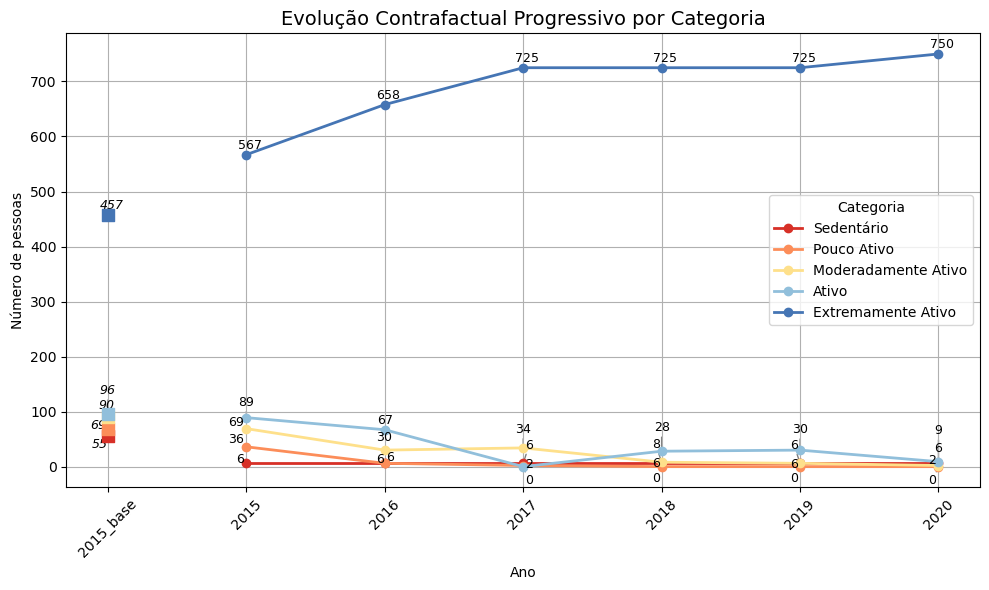

In [155]:
import matplotlib.pyplot as plt
from adjustText import adjust_text 
import pandas as pd

# Plot
fig, ax = plt.subplots(figsize=(10,6))

# Cores para cada categoria
cores = ["#d73027", "#fc8d59", "#fee08b", "#91bfdb", "#4575b4"]

# Lista para armazenar os textos
textoss = []

# Obter as colunas reais do DataFrame
colunas_reais =  contagem_cf.columns.tolist()

# Separar 2015_base dos outros anos
coluna_2015_base = '2015_base'
colunas_anos_normais = [col for col in colunas_reais if col != coluna_2015_base]

# Definir posições no eixo x
posicao_2015_base = 2014
posicoes_anos_normais = []
for col in colunas_anos_normais:
    try:
        posicoes_anos_normais.append(int(col))
    except ValueError:
        posicoes_anos_normais.append(len(posicoes_anos_normais) + 2015)

for i, categoria in enumerate(categorias_atividade):
    # Separar o valor de 2015_base dos outros anos
    valor_2015_base = contagem_cf.loc[categoria, coluna_2015_base]
    valores_anos_normais = [contagem_cf.loc[categoria, col] for col in colunas_anos_normais]
    
    # Plotar linha principal (anos normais)
    linha = ax.plot(posicoes_anos_normais, valores_anos_normais, marker='o', color=cores[i], label=categoria, linewidth=2)
    
    # Plotar 2015_base como ponto separado (com marcador diferente)
    ax.scatter(posicao_2015_base, valor_2015_base, color=cores[i], marker='s', s=80, zorder=5)
    
    # Adicionar textos para anos normais
    for x, y in zip(posicoes_anos_normais, valores_anos_normais):
        txt = ax.text(x, y, str(int(y)), fontsize=9, ha='center', va='bottom')
        textoss.append(txt)
    
    # Adicionar texto para 2015_base
    txt_base = ax.text(posicao_2015_base, valor_2015_base, str(int(valor_2015_base)), 
                      fontsize=9, ha='center', va='bottom', style='italic')
    textoss.append(txt_base)

# Ajuste do gráfico
adjust_text(textoss, only_move={'points':'y', 'text':'y'}, arrowprops=dict(arrowstyle='-', color='gray'))

# Configurações do gráfico
ax.set_title("Evolução Contrafactual Progressivo por Categoria", fontsize=14)
ax.set_xlabel("Ano")
ax.set_ylabel("Número de pessoas")

# Configurar eixo x com ambos os pontos
xticks = [posicao_2015_base] + posicoes_anos_normais
xlabels = ['2015_base'] + [str(col) for col in colunas_anos_normais]
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=45 if len(xlabels) > 6 else 0)

ax.legend(title="Categoria")
ax.grid(True)

plt.tight_layout()
plt.show()

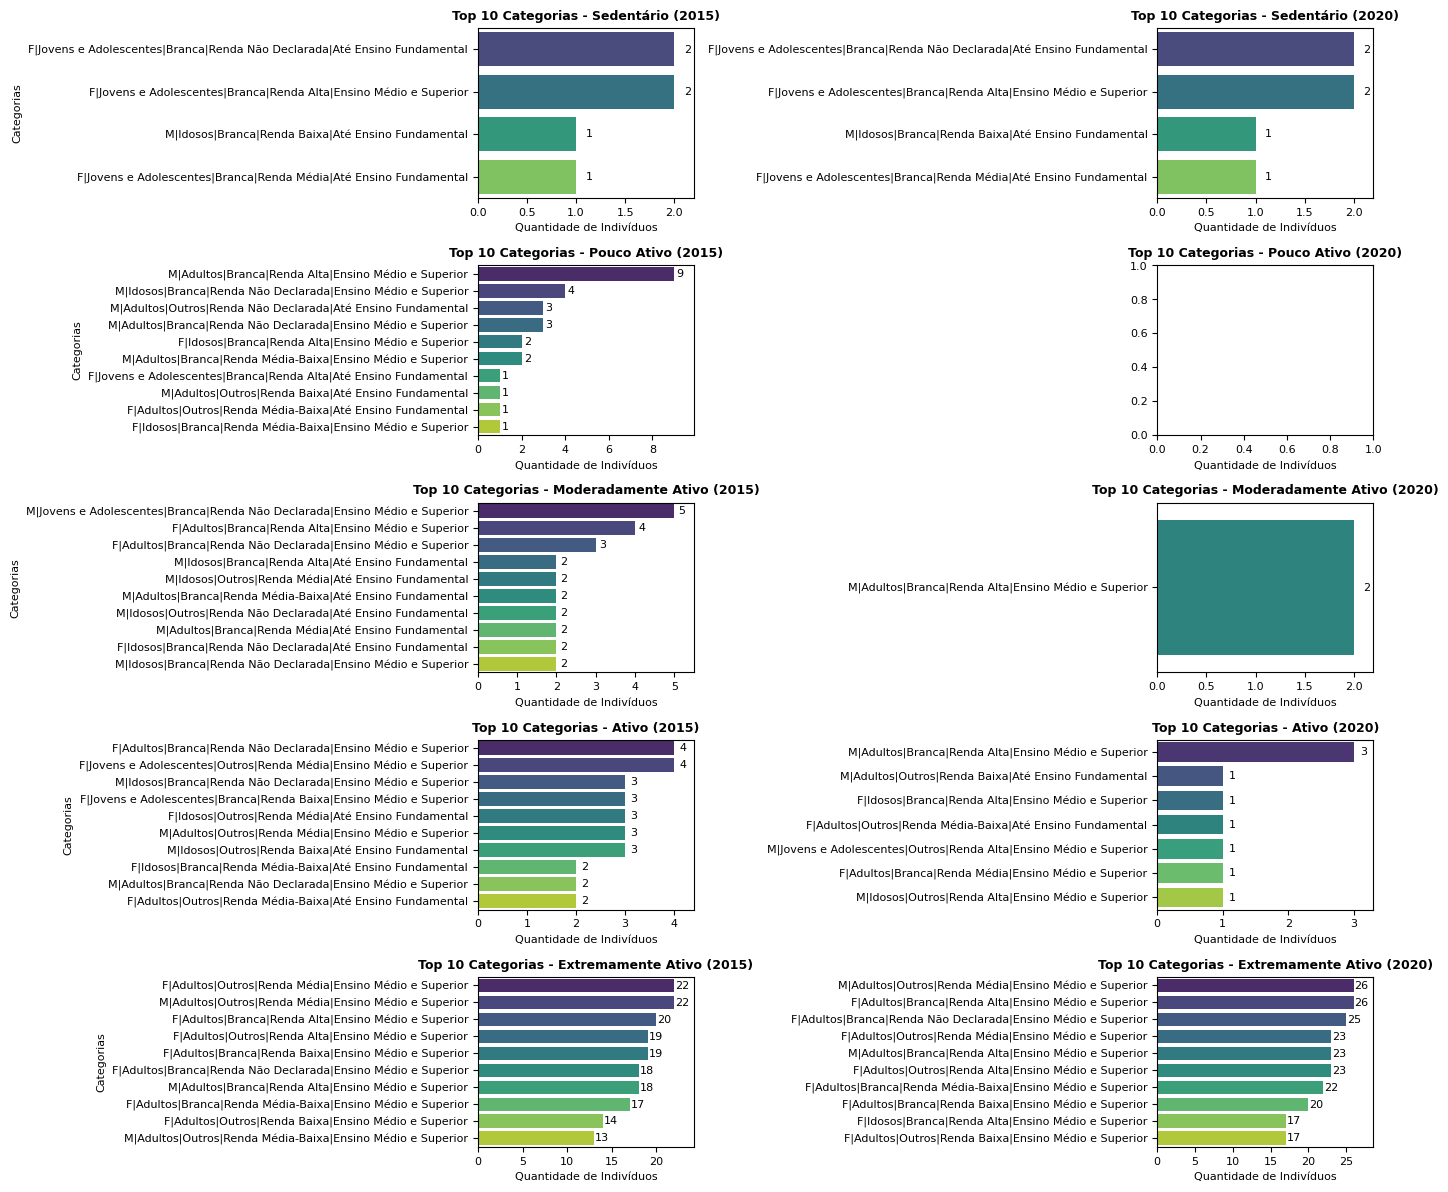

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Função de plotagem  das categorias mais frequentes em 2015 e 2020 contrafactual
def plot_top10_categorias_por_atividade_2015_2020(df):
    col_atividade_2015 = 'Classificacao_Atividade_CF_2015' # imc contrafactual 2015
    col_atividade_2020 = 'Classificacao_Atividade_CF_2020' # imc contrafactual 2020
    col_categoria = 'Categorias'
    #listagem das categorias de atividade fisica
    categorias_atividade = ["Sedentário", "Pouco Ativo", "Moderadamente Ativo", "Ativo", "Extremamente Ativo"]



#criacao dos subplots  de  5 categorias em relacao aos 2 anos
    fig, axs = plt.subplots(5, 2, figsize=(14, 12))
    axs = axs.flatten()
# loop para cada categorias de atividade 
    for i, atividade in enumerate(categorias_atividade):
        
        df_2015 = df[df[col_atividade_2015] == atividade]
        cont_2015 = df_2015[col_categoria].value_counts().head(10).reset_index()
        cont_2015.columns = ['Categorias', 'Quantidade']
# barras do grafico
        sns.barplot(
            data=cont_2015,
            y='Categorias',
            x='Quantidade',
            hue='Categorias',
            legend=False,
            palette='viridis',
            ax=axs[i*2]
        )

        for j, v in enumerate(cont_2015['Quantidade']):
            axs[i*2].text(v + 0.1, j, f"{v}", color='black', va='center', fontsize=8)

        axs[i*2].set_title(f'Top 10 Categorias - {atividade} (2015)', fontsize=9, fontweight='bold')
        axs[i*2].set_xlabel('Quantidade de Indivíduos', fontsize=8)
        axs[i*2].set_ylabel('Categorias', fontsize=8)
        axs[i*2].tick_params(axis='both', which='major', labelsize=8)
        axs[i*2].set_xlim(0, max(1, cont_2015['Quantidade'].max() * 1.1))

        # aplicacao par ao 2020
        df_2020 = df[df[col_atividade_2020] == atividade]
        cont_2020 = df_2020[col_categoria].value_counts().head(10).reset_index()
        cont_2020.columns = ['Categorias', 'Quantidade']
# barras
        sns.barplot(
            data=cont_2020,
            y='Categorias',
            x='Quantidade',
            hue='Categorias',
            legend=False,
            palette='viridis',
            ax=axs[i*2 + 1]
        )

        for j, v in enumerate(cont_2020['Quantidade']):
            axs[i*2 + 1].text(v + 0.1, j, f"{v}", color='black', va='center', fontsize=8)

        axs[i*2 + 1].set_title(f'Top 10 Categorias - {atividade} (2020)', fontsize=9, fontweight='bold')
        axs[i*2 + 1].set_xlabel('Quantidade de Indivíduos', fontsize=8)
        axs[i*2 + 1].set_ylabel('')
        axs[i*2 + 1].tick_params(axis='both', which='major', labelsize=8)
        axs[i*2 + 1].set_xlim(0, max(1, cont_2020['Quantidade'].max() * 1.1))

    plt.tight_layout(pad=1.0)
    plt.show()

# chamada da funcao 

plot_top10_categorias_por_atividade_2015_2020(df)

# Classes_ Nivel de Atividade Física

# Simulação

In [157]:
import pandas as pd
#carregamento do banco de dados associado ao consumo alimentar
df_calorias = pd.read_excel(
    r'C:\Users\vimed\Downloads\Dados_Mestrado_07_05_2025 (1).NeW_Teste_@_Ajustado_Ajuste.xlsx',
    sheet_name='Tabela Auxiliar_Consumo Caloric',
    engine='openpyxl'
)
df_calorias.drop(columns=[
    'Coluna1',
    'Coluna2',
    'Unnamed: 4',
    'Unnamed: 5',
    'Unnamed: 6',
    'Unnamed: 7',
    'Chavemento pof',
    'Kcal-dia.1'
], inplace=True)

df_calorias

,Chavemento pof e ISA,Kcal-dia
0,M|Adultos|Outros|Renda Alta|Ensino Médio e Sup...,1306.500
1,M|Jovens e Adolescentes|Outros|Renda Média-Bai...,829.630
2,M|Adultos|Outros|Renda Média-Baixa|Até Ensino ...,1455.890
3,F|Adultos|Outros|Renda Alta|Ensino Médio e Sup...,2636.490
4,M|Adultos|Branca|Renda Média|Ensino Médio e Su...,1420.615
...,...,...
2357,M|Adultos|Outros|Renda Não Declarada|Até Ensin...,1161.565
2358,M|Adultos|Branca|Renda Não Declarada|Ensino Mé...,2029.671
2359,M|Adultos|Branca|Renda Não Declarada|Até Ensin...,2046.021
2360,F|Idosos|Outros|Renda Média|Até Ensino Fundame...,816.652


In [158]:
df_original =df.copy()

In [159]:
# Bibliotecas Necessárias para a Simulação
import torch
import numpy as np
import pandas as pd
import random
import warnings

# Necessária a Incorporação de uma Fixador-Aleatorio para Garantir Reprodutibilidade do Modelo Probabilistico
SEED = 42
random.seed(SEED)   # Fixador para controle dos numeros aleatorios gerados do Python
np.random.seed(SEED)  # Fixador para controle dos numeros aleatorios gerados da Biblioteca Numpy
torch.manual_seed(SEED)  # Fixador para controle dos numeros aleatorios gerados da Biblioteca do Pythorch
# sincronização.
if torch.cuda.is_available(): # Verificação se há disponivel uma CPU CUDA Compatível, se houver, ele garante que todos os processos paralelizados possuam o mesmo fixador em paralelo.
    torch.cuda.manual_seed_all(SEED)

## Conversão e Padronização de Datas na Simulação com Tratamento de ERRO, com callback
def converter_data_brasil_ou_americano(data):
    if pd.isna(data):
        return pd.NaT
    #preserva as datas já convertidas
    if isinstance(data, (pd.Timestamp, pd.DatetimeTZDtype)):
        return data
    # realização vai mais uma verificação  de conversão de data com trtamento de erro via padrão brasileiro e americano
    if isinstance(data, str):
        data = data.strip()
        if data == '':
            return pd.NaT
        #tratamento  via tentativa DD/MM/AAAA
    try:
        return pd.to_datetime(data, format='%d/%m/%Y', errors='raise')
    except Exception:
        try: # com tratamento de erro YYYY/MM/DD
            return pd.to_datetime(data, format='%Y-%m-%d', errors='raise')
        except Exception:
            warnings.warn(f"Erro a padronizar/converter: {data}. Retornando NaT.")
        return pd.NaT

#####################################################################################################
#Execução das Simulações Via Pytorch

# Função da Simulação Geral
def simulacao_torch(df_original, df_calorias, num_semanas, num_simulacoes):

    df = df_original.copy().reset_index(drop=True)
    
    # Aplicar conversão de data(funcao supracitada)
    df['datanasc'] = df['datanasc'].apply(converter_data_brasil_ou_americano)
       
    # Conferência das colunas importantes para a simulação
    colunas_obrigatorias = ['peso', 'datanasc', 'sexo', 'altura', 'id', 'Categorias']
    for coluna in colunas_obrigatorias:
        if coluna not in df.columns:
            raise ValueError(f"Coluna Ausente: {coluna}")
        
    # Anos da simulação com relação aos fatores de atividade fisica
    anos = list(range(2015, 2021))  # 2015 a 2020

    # Mapeamento de anos para colunas de fatores 
    mapeamento_colunas_fatores = {
        2015: 'Fator_Classificacao_Atividade_CF_2015',
        2016: 'Fator_Classificacao_Atividade_CF_2016', 
        2017: 'Fator_Classificacao_Atividade_CF_2017',
        2018: 'Fator_Classificacao_Atividade_CF_2018',
        2019: 'Fator_Classificacao_Atividade_CF_2019',
        2020: 'Fator_Classificacao_Atividade_CF_2020'
    }

    # Verificar quais colunas existem no dataframe
    colunas_existentes = df.columns
    mapeamento_fatores_categoria = {}
    # criação de um dicionario para cada categoria  e ano sob as simulações
    for categoria in df['Categorias'].unique():
        for ano in anos:
            coluna_fator = mapeamento_colunas_fatores.get(ano)
            
            if coluna_fator and coluna_fator in colunas_existentes:
                valores = df.loc[(df['Categorias'] == categoria) & (df[coluna_fator].notna()), coluna_fator].unique()
                # Criação de Tratamento de erro, caso não encontre, usar o valor padrão de  como sedentário.
                if len(valores) > 0:
                    mapeamento_fatores_categoria[(categoria, ano)] = valores.astype(np.float32)
                else:
                    mapeamento_fatores_categoria[(categoria, ano)] = np.array([1.2], dtype=np.float32)
                    print(f" Categoria '{categoria}', ano {ano} - uso do  valor  1.2")
            else:
                mapeamento_fatores_categoria[(categoria, ano)] = np.array([1.2], dtype=np.float32)
                print(f"Coluna '{coluna_fator}' não achada  ano {ano} - usado o valor  1.2")

    # Processamento das Datas de Aniversários, Idade e Peso, e Sexo
    dias_nascimento = df['datanasc'].dt.normalize().values.astype('datetime64[D]').astype('int64')
    num_individuos = len(df) 
    ids = df['id'].values
    peso_inicial = df['peso'].astype(float).values.astype(np.float32) 
    altura = df['altura'].astype(float).values.astype(np.float32)
    sexo = (df['sexo'].astype(str) == 'M').astype(np.float32).values
    
    # Mapeando as Categorias dos Individuos.
    categorias, indices_categorias = np.unique(df['Categorias'].values, return_inverse=True)
    indices_categorias = indices_categorias.astype(np.int64)
    num_categorias = len(categorias)

    # Uso do Dataframe das Calorias por Categorias por pelo metod 
    mapeamento_calorias_categoria = {}
    for categoria in categorias:
        valores = df_calorias.loc[df_calorias['Chavemento pof e ISA'] == categoria, 'Kcal-dia'].dropna().astype(float).values.astype(np.float32)
        mapeamento_calorias_categoria[categoria] = valores
        
    # Método do Map paras as categorias
    valores_concatenados = np.concatenate([mapeamento_calorias_categoria[c] for c in categorias])
    indices_categorias_map = {}
    comeco_idx = 0
    for c in categorias:
        fim_idx = comeco_idx + len(mapeamento_calorias_categoria[c])
        indices_categorias_map[c] = (comeco_idx, fim_idx)
        comeco_idx = fim_idx
    valores_concatenados_t = torch.tensor(valores_concatenados, dtype=torch.float32)

    # Converter para tensores
    tensor_peso_inicial = torch.tensor(peso_inicial)
    tensor_altura = torch.tensor(altura)
    tensor_sexo = torch.tensor(sexo)
    tensor_dias_nascimento = torch.tensor(dias_nascimento)
    tensor_indices_categorias = torch.tensor(indices_categorias, dtype=torch.long)
    
    # Input para Data Inicial da Simulação
    data_base = np.datetime64('2015-01-01').astype('datetime64[D]').astype('int64')
    
    # Armazenamento dos Resultados
    resultados = []
    # funcao para determinar o índice do ano com base na semana atual de simulacao
    def semana_para_ano_idx(semana):
        return min(semana // 52, len(anos)-1)
        
    for simulacao in range(num_simulacoes):
        peso_atual = tensor_peso_inicial.clone()
        #Inicializacao do tensor para o armazenamento do balanço energetico semanal
        balanco_semanas = torch.empty((num_individuos, num_semanas), dtype=torch.float32)
        # loop das semanas
        for semana in range(num_semanas):
            dias_passados = semana * 7
            dia_atual = data_base + dias_passados
            # calculo da idade do individuo, usando  a semana atual da simulação e a data de nascimento do individuo
            idade = ((dia_atual - tensor_dias_nascimento) // 365).to(torch.float32)

            ano_idx = semana_para_ano_idx(semana)
            ano = anos[ano_idx]
            # fator sorteado para cada individuo por semana
            fator_sorteado = torch.zeros(num_individuos)
            # Tensores
            for i, categoria in enumerate(categorias):
                indices_cat = (tensor_indices_categorias == i).nonzero(as_tuple=True)[0]
                if len(indices_cat) > 0:
                    fatores_disponiveis = mapeamento_fatores_categoria.get((categoria, ano), [1.2])
                    fatores_tensor = torch.tensor(fatores_disponiveis, dtype=torch.float32)
                    indices = torch.randint(0, len(fatores_tensor), (len(indices_cat),))
                    fator_sorteado[indices_cat] = fatores_tensor[indices]
            # Equação de Taxa Metabolica via St. Miffins por meio de vetor
            tmb_dia = (10.0 * peso_atual) + (6.25 * tensor_altura * 100.0) - (5.0 * idade) + (5.0 * tensor_sexo) + (-161.0 * (1.0 - tensor_sexo))
            gasto_semanal = tmb_dia * 7.0 * fator_sorteado
                        
            # Calorias por categoria
            idxs = []
            #sorteio calorico para 7 dias
            for idx in range(num_individuos):
                cat = categorias[tensor_indices_categorias[idx]]
                comeco, fim = indices_categorias_map[cat]
                rand_idx = torch.randint(comeco, fim, (7,))
                idxs.append(rand_idx.unsqueeze(0))
                
            idxs = torch.cat(idxs, dim=0)
            # aplicação dos limites de sorteio calorico entre 800 kcal até 5000 kcal por dia
            consumo_diario = torch.clamp(valores_concatenados_t[idxs], min=800.0, max=5000.0)
            consumo_semanal = consumo_diario.sum(dim=1)
            # Calculo do Balanço Energetico
            balanco_energetico = consumo_semanal - gasto_semanal
            # Estabelecimento do Limite inferior do peso com base no estado atual(na semana do individuo em porcentagem) e suavizacao
            limite_deficit = peso_atual * 0.008 * 7700.0 * (0.92 ** min(semana, 40))
            #Estabelecimento do Limite Superior do peso com base no estado atual(na semana do individuo em porcentagem) e suavizacao exponencial
            limite_superavit = peso_atual * 0.02 * 7700.0 * (0.92 ** min(semana, 40))
            # Clipagem via limites aceitaveis adotados
            balanco_energetico = torch.clamp(balanco_energetico, min=-limite_deficit, max=limite_superavit)
            balanco_semanas[:, semana] = balanco_energetico
            # Calculo do Peso do Individuo em determinanda semana.
            peso_atual = peso_atual + (balanco_energetico / 7700.0)
        # movimentar os dados dO Tensor flow para cpu(caso estejam na GPU) e converter para numpy
        balanco_cpu = balanco_semanas.detach().cpu().numpy()
        # criacao do dataframe  com cada coluna representando o balanço energetico por semana
        df_balanco = pd.DataFrame(balanco_cpu, columns=[f'semana_{i+1}' for i in range(num_semanas)])
        # adicionar cada id para identificar o individuo da simulacao
        df_balanco['id'] = ids
        # enumeracao  do numero da simulacao
        df_balanco['simulacao'] = simulacao + 1
        # armazenamento do dataframe  atual na lista de resutlados
        resultados.append(df_balanco)
        

    return resultados

# Chamada da Função com os Inputs de Semanas e Quantidades de Semanas Desejadas
resultados = simulacao_torch(df_original, df_calorias, num_semanas=314, num_simulacoes=100)


# Pós-Processamento

In [160]:
#Concatenando os resultados por ano
df_simulacao = pd.concat(resultados, ignore_index=True)
# contagem das semanas por ano
semanas_por_ano = 52
# range de anos para percorer
anos = list(range(2015, 2021))

df_peso_inicial = df[['id', 'peso', 'altura']].drop_duplicates().copy()
# calcula o peso contrafactual acumulado por ano com base nas semanas da simulação
def calcular_peso_ano(df_sim, df_peso_inicial, anos, semanas_por_ano):
    pesos = {}
    for i, ano in enumerate(anos, start=1):
        semanas = i * semanas_por_ano
        colunas = [f'semana_{j+1}' for j in range(semanas)]
        acumulado = df_sim.groupby('id')[colunas].mean()
        pesos[ano] = df_peso_inicial.set_index('id')['peso'] + (acumulado.sum(axis=1) / 7700)
    return pesos
# Transformação dos pesos em relação ao contrafactaul
pesos_por_ano_contrafactual = calcular_peso_ano(df_simulacao, df_peso_inicial, anos, semanas_por_ano)

# Reindexação dos individuos, considerando o peso inicial na simulação,criando Dataframe final do  ID unico para peso e IMC
df_final = df[['id', 'Categorias', 'altura']].drop_duplicates().copy().set_index('id')
df_final['Peso_2015_base'] = df_peso_inicial.set_index('id')['peso']

# Loop do Calculo ano a ano do Peso contrafactaul
for ano in anos:
    df_final[f'Peso_{ano}_contrafactual'] = pesos_por_ano_contrafactual[ano].reindex(df_final.index)
df_final['IMC_2015_base'] = df_final['Peso_2015_base'] / (df_final['altura'] ** 2)
# Loop do Calculo ano a ano do IMC contrafactaul
for ano in anos:
    df_final[f'IMC_{ano}_contrafactual'] = df_final[f'Peso_{ano}_contrafactual'] / (df_final['altura'] ** 2)
df_final.reset_index(inplace=True)

# Função parar para mostrar as estatisticas descritivas dos individuos, considerando peso e IMC
def formatar_describe_planilha(df, tipo):
    dados = {}
    base = df[f'{tipo}_2015_base'].describe() # calculo das estatisticas de 2015 base
    dados['Estatística'] = base.index.tolist() + ['n_pessoas'] # adiciona o numero de pessoas
    dados[f'{tipo}_2015_base'] = base.values.tolist() + [df[f'{tipo}_2015_base'].count()]
    #loop de interacao anual para fazer isso 
    for ano in anos:
        d = df[f'{tipo}_{ano}_contrafactual'].describe()
        dados[f'{tipo}_{ano}_contrafactual'] = d.values.tolist() + [df[f'{tipo}_{ano}_contrafactual'].count()]
    return pd.DataFrame(dados).round(2)

# Exibir as estatisticas das Simulações
print("Estatistica ")
print("\n Peso da Simualação(2015-2020)") 
print(formatar_describe_planilha(df_final, 'Peso').to_string(index=False))
print("\nImc")
print(formatar_describe_planilha(df_final, 'IMC').to_string(index=False))

# Definição do Ultimo ano de Simulação 
ultimo_ano = anos[-1]
peso = df_final[f'Peso_{ultimo_ano}_contrafactual'].describe()
imc = df_final[f'IMC_{ultimo_ano}_contrafactual'].describe()

#Exibir estatistica do ultimo ano
print(f"\n-Finais {ultimo_ano} -")
print("\nPeso")
print(pd.DataFrame({'Estatística': peso.index.tolist()+['n_pessoas'], # Contagem de Individuos
                    'Valor': peso.values.tolist()+[df_final[f'Peso_{ultimo_ano}_contrafactual'].count()]}).round(2).to_string(index=False))
print("\nImc:")
print(pd.DataFrame({'Estatística': imc.index.tolist()+['n_pessoas'],
                    'Valor': imc.values.tolist()+[df_final[f'IMC_{ultimo_ano}_contrafactual'].count()]}).round(2).to_string(index=False))


Estatistica 

 Peso da Simualação(2015-2020)
Estatística  Peso_2015_base  Peso_2015_contrafactual  Peso_2016_contrafactual  Peso_2017_contrafactual  Peso_2018_contrafactual  Peso_2019_contrafactual  Peso_2020_contrafactual
      count          767.00                   767.00                   767.00                   767.00                   767.00                   767.00                   767.00
       mean           70.75                    65.54                    64.77                    63.98                    63.19                    62.41                    61.64
        std           15.75                    13.51                    13.22                    12.96                    12.70                    12.45                    12.22
        min           34.00                    33.82                    33.68                    33.27                    32.88                    32.53                    32.21
        25%           60.00                    55.90             

# Visulização

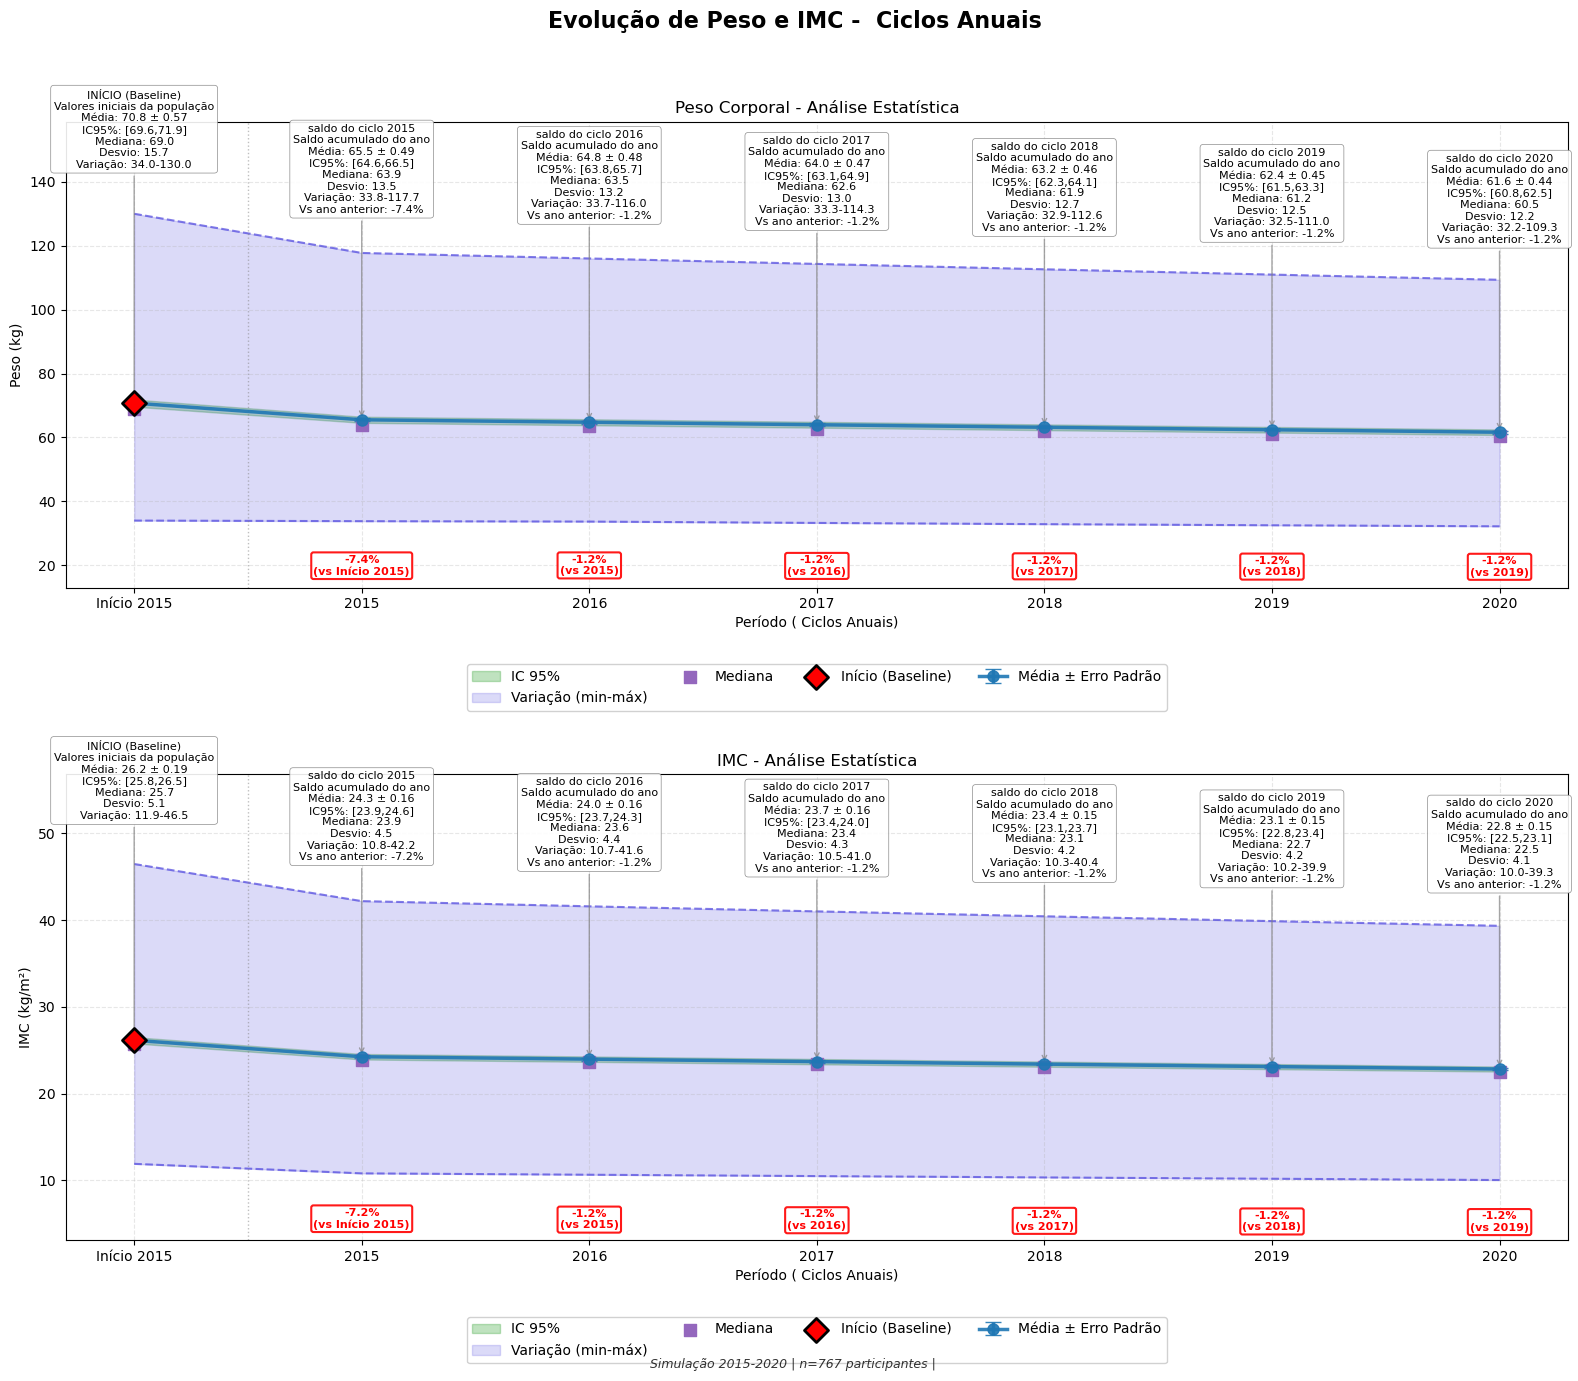

In [161]:
# Bibliotecas usadas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator

# calculo estatísticas descritivas e intervalos de confiança (IC95%)
def analisar_estatisticas_peso_imc(df_final):
    anos = [2015, 2016, 2017, 2018, 2019, 2020] # Anos analisados
    anos_com_base = ['Início 2015'] + anos # Anos de Inicio (Baseline)
    cores = ['#1f77b4', "#0ecfff", '#2ca02c', "#4e46de", '#9467bd']# Paleta de Cores
# estilo e ajuste de fontes
    plt.style.use('default')
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10})
# funcao  para retorno do tipo e ano  em relacao ao coluna do dataframe
    def nome_coluna(tipo, ano):
        return f'{tipo}_2015_base' if ano == 'Início 2015' else f'{tipo}_{ano}_contrafactual'
# funcao para calculo de  media, desvio, ic95%, variacao e amplitude para cada ano
    def calcular_estatisticas(tipo):
        resultados = {k: [] for k in ['medias','medianas','desvios','erros_medios','ic95','variacoes',
                                      'minimos','maximos','amplitude','n_amostras','dentro_ic']}
        for i, ano in enumerate(anos_com_base):
            if nome_coluna(tipo, ano) not in df_final: 
                continue
            dados = df_final[nome_coluna(tipo, ano)].dropna()
            if dados.empty: 
                continue
            #estatistica
            media, desvio, erro = dados.mean(), dados.std(), dados.sem()
            ic = 1.96 * erro
            minimo, maximo = dados.min(), dados.max()
            amplitude = maximo - minimo
            dentro_ic = ((dados >= media - ic) & (dados <= media + ic)).mean() * 100
            # variacao porcentual em relacao ao ano anterior
            if i == 0:
                variacao = 0
            else:
                anterior = df_final[nome_coluna(tipo, anos_com_base[i-1])].dropna()
                variacao = ((media - anterior.mean()) / anterior.mean() * 100) if len(anterior) > 0 else 0
        # armazenamento de resultados  no dicionario
            valores = [media, dados.median(), desvio, erro, ic, variacao, minimo, maximo, amplitude, len(dados), dentro_ic]
            for chave, valor in zip(resultados.keys(), valores):
                resultados[chave].append(valor)
        # conversao em lista via Numpy
        return {k: np.array(v) for k, v in resultados.items()}
# funcao para os graficos com a media, IC95%, MIN/MAX, mediana, mediana e variacao anual
    def criar_grafico(ax, dados, titulo, label_y):
        x = np.arange(len(dados['medias']))
    # curva principal: media +- erro padrao
        ax.errorbar(x, dados['medias'], yerr=dados['erros_medios'], fmt='-o', capsize=6, ms=8, lw=2.5,
                    color=cores[0], ecolor=cores[0], alpha=.9, label='Média ± Erro Padrão', zorder=5)
        ax.fill_between(x, dados['medias']-dados['ic95'], dados['medias']+dados['ic95'],
                        color=cores[2], alpha=.3, label='IC 95%')
        #linha de confiança e variação total
        ax.fill_between(x, dados['minimos'], dados['maximos'], color=cores[3], alpha=.2, label='Variação (min-máx)')
        ax.plot(x, dados['minimos'], '--', color=cores[3], alpha=.7)
        ax.plot(x, dados['maximos'], '--', color=cores[3], alpha=.7)
        ax.scatter(x, dados['medianas'], marker='s', s=80, color=cores[4], zorder=5, label='Mediana')
        ax.scatter([0], [dados['medias'][0]], marker='D', s=150, color='red',
                   edgecolors='black', lw=2, zorder=10, label='Início (Baseline)')
        ax.axvline(0.5, color='gray', ls=':', alpha=.5, lw=1)
        # informações textuais e para cada ponto temporal no anao
        for i in range(len(x)):
            media, erro, ic, dentro_ic, mediana, minimo, maximo, n, amplitude, variacao = (
                dados[ch][i] for ch in ['medias','erros_medios','ic95','dentro_ic','medianas',
                                        'minimos','maximos','n_amostras','amplitude','variacoes']
            )
            nome = 'Início 2015' if i == 0 else anos_com_base[i]
            texto = (f'INÍCIO (Baseline)\nValores iniciais da população\n' if i == 0 
                     else f'saldo do ciclo {nome}\nSaldo acumulado do ano\n') + \
                    f'Média: {media:.1f} ± {erro:.2f}\nIC95%: [{media-ic:.1f},{media+ic:.1f}]\n' \
                    f'Mediana: {mediana:.1f}\nDesvio: {dados["desvios"][i]:.1f}\n' \
                    f'Variação: {minimo:.1f}-{maximo:.1f}' + \
                    ('' if i == 0 else f'\nVs ano anterior: {variacao:+.1f}%')

            ax.annotate(texto, xy=(x[i], media), xytext=(x[i], maximo + amplitude * 0.15), ha='center',
                        fontsize=8, color='black',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9, ec="gray", lw=0.5),
                        arrowprops=dict(arrowstyle='->', color='gray', alpha=.7, lw=1))
            #exibicao de nivel porcentual
            if i > 0:
                cor = 'green' if variacao >= 0 else 'red'
                ax.annotate(f'{variacao:+.1f}%\n(vs {anos_com_base[i-1]})', xy=(x[i], media),
                            xytext=(x[i], minimo - amplitude * 0.2), ha='center', fontsize=8,
                            color=cor, weight='bold',
                            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=.9, ec=cor, lw=1.5))
# Configuração de eixos
        ax.set(title=titulo, xlabel='Período ( Ciclos Anuais)', ylabel=label_y)
        ax.set_xticks(x)
        ax.set_xticklabels(anos_com_base[:len(x)])
        ax.grid(True, alpha=.3, ls='--')
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, framealpha=.9)
        ax.xaxis.set_major_locator(MultipleLocator(1))
        amp_max = dados['amplitude'].max()
        ax.set_ylim(dados['minimos'].min() - amp_max * .2, dados['maximos'].max() + amp_max * .3)
# Calculo  das estatisticas para o  Peso e IMC
    estat_peso, estat_imc = calcular_estatisticas('Peso'), calcular_estatisticas('IMC')
    #Criação de Dois Subplots
    fig, eixos = plt.subplots(2, 1, figsize=(16, 14))
    fig.suptitle('Evolução de Peso e IMC -  Ciclos Anuais', fontsize=16, fontweight='bold', y=.98)

    criar_grafico(eixos[0], estat_peso, 'Peso Corporal - Análise Estatística', 'Peso (kg)')
    criar_grafico(eixos[1], estat_imc, 'IMC - Análise Estatística', 'IMC (kg/m²)')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=.4)
    fig.text(0.5, 0.01, f'Simulação {anos[0]}-{anos[-1]} | n={len(df_final)} participantes | ', ha='center', fontsize=9, style='italic', alpha=.8)
    plt.show()
    return estat_peso, estat_imc
#chamada 
estat_peso, estat_imc = analisar_estatisticas_peso_imc(df_final)
    

# Visualização Estados Nutricionais

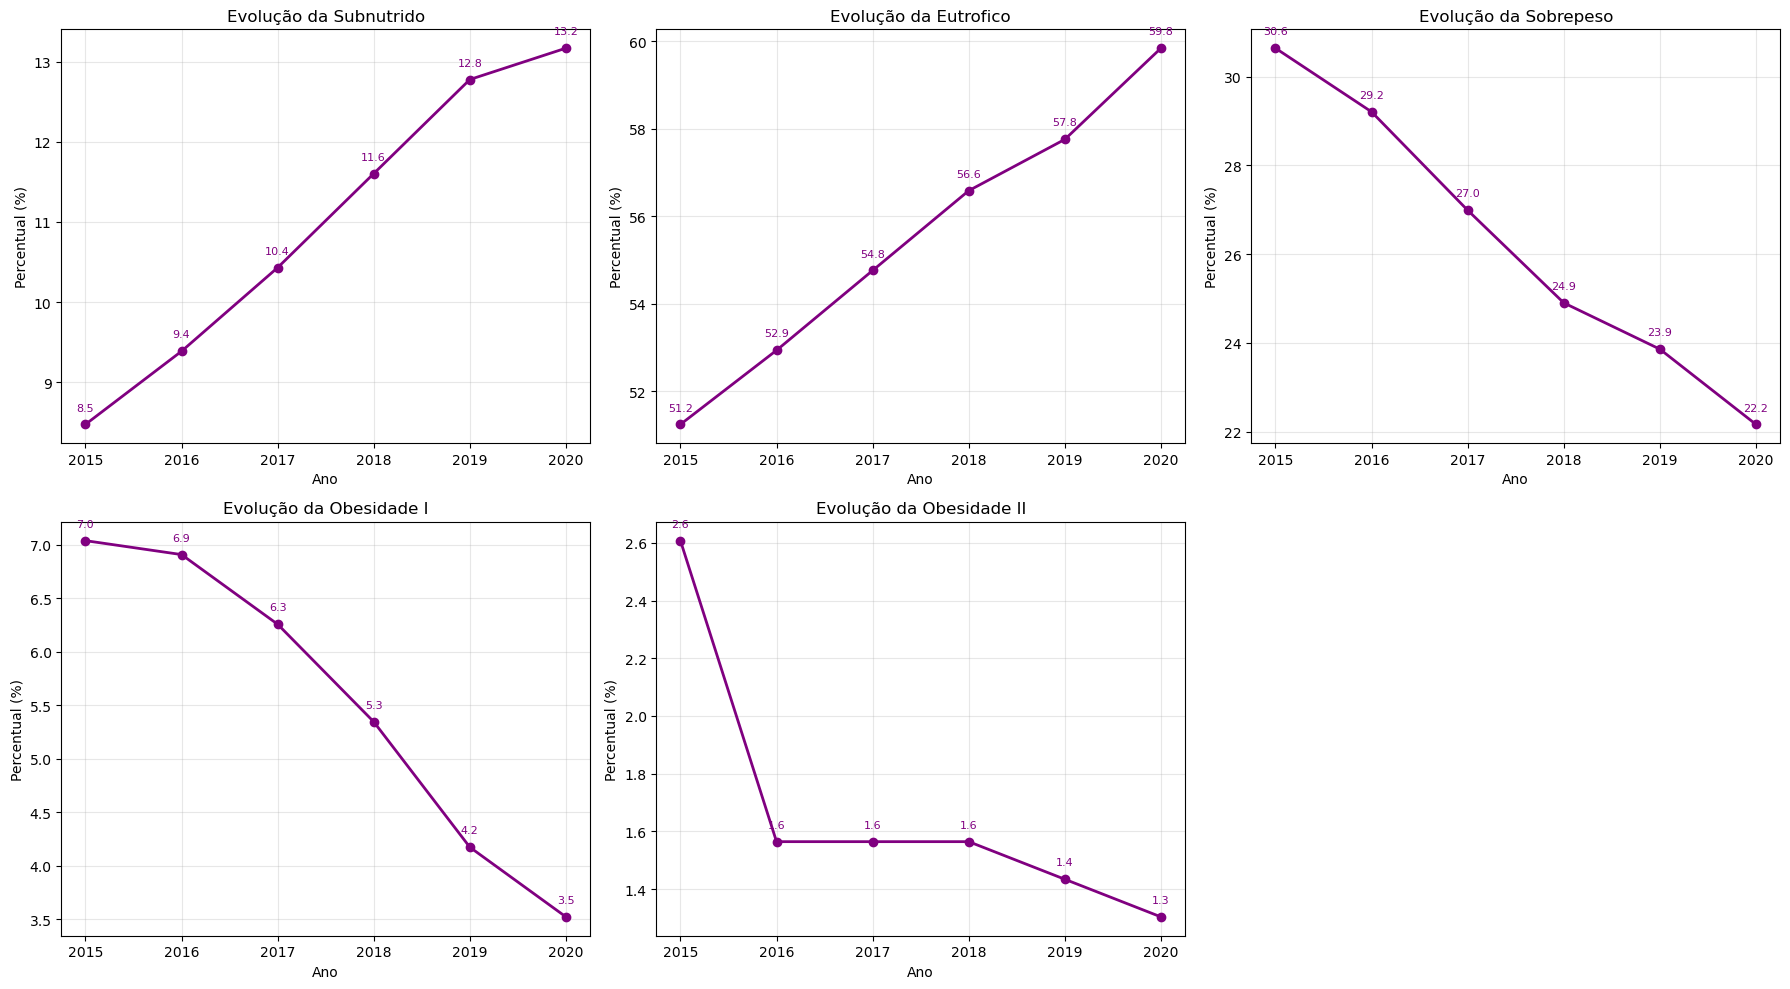

In [162]:
# Bibliotecas Necessarias
import matplotlib.pyplot as plt
import pandas as pd

# Classificação conforme IMC

def classificar_imc(imc):
    if imc < 18.5: 
        return 'Subnutrido'
    elif 18.5 <= imc < 25: 
        return 'Eutrofico'
    elif 25 <= imc < 30: 
        return 'Sobrepeso'
    elif 30 <= imc < 35: 
        return 'Obesidade I'
    else: 
        return 'Obesidade II'

# Função para definir a evolução no grafico
def plotar_evolucao(df_final):
    categorias = ['Subnutrido', 'Eutrofico', 'Sobrepeso', 'Obesidade I', 'Obesidade II']
    
    # colunas do dataframe para serem coletados
    colunas_imc = [
        'IMC_2015_contrafactual', 'IMC_2016_contrafactual', 
        'IMC_2017_contrafactual', 'IMC_2018_contrafactual',
        'IMC_2019_contrafactual', 'IMC_2020_contrafactual'
    ]# anos  medidos
    anos = [2015, 2016, 2017, 2018, 2019, 2020]
     #grade de subplots (2 linhas x 3 colunas)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
   # Loop para cada categoria de  imc
    for idx, categoria in enumerate(categorias):
        if idx < len(axes):
            ax = axes[idx]
            percentuais = []
            for col in colunas_imc:
                classificacoes = df_final[col].apply(classificar_imc)
                percentual = (classificacoes == categoria).sum() / len(df_final) * 100
                percentuais.append(percentual)

            # Gráfico
            line = ax.plot(anos, percentuais, 'o-', linewidth=2, color='purple')[0]

            #  percentual
            for ano, percentual in zip(anos, percentuais):
                if percentual >= 0:
                    ax.annotate(f'{percentual:.1f}', 
                                (ano, percentual), 
                                textcoords="offset points", 
                                xytext=(0,10), 
                                ha='center', 
                                fontsize=8,
                                color=line.get_color())
            
            ax.set_title(f'Evolução da {categoria}')
            ax.set_xlabel('Ano')
            ax.set_ylabel('Percentual (%)')
            ax.grid(True, alpha=0.3)
            ax.set_xticks(anos)

    if len(categorias) < len(axes):
        for idx in range(len(categorias), len(axes)):
            fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

# chamada 
plotar_evolucao(df_final)


# Visualização Classes Mais Impactadas

In [163]:
df= df_final

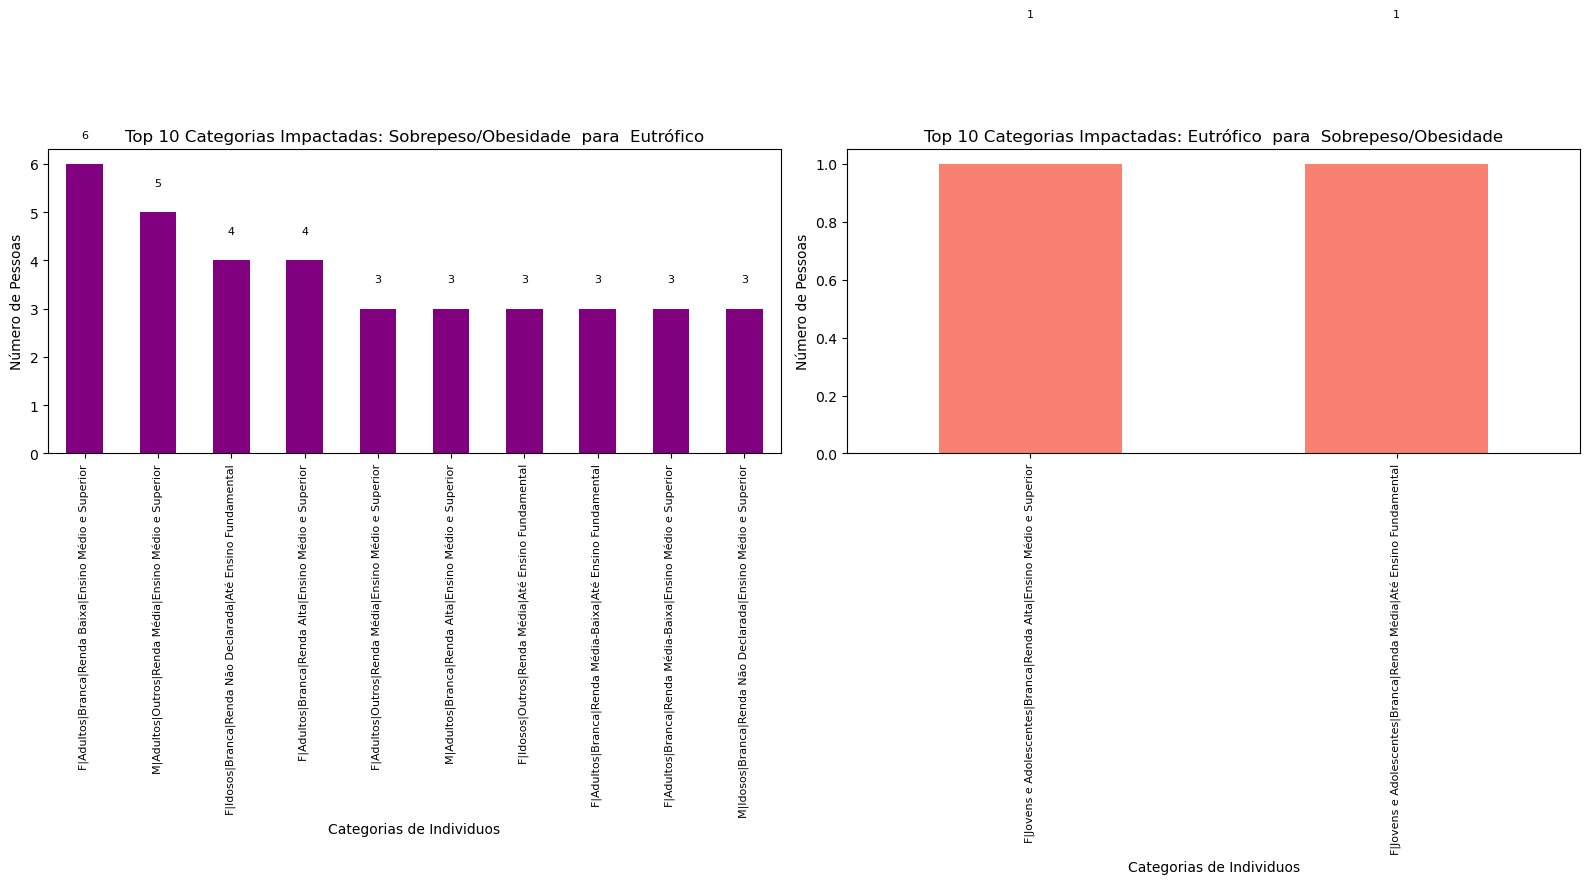

In [164]:
import pandas as pd
import matplotlib.pyplot as plt

 # classificação  do IMC
def classificar_imc(imc):
    if imc < 18.5:
        return 'Subnutrido'
    elif imc < 25:
        return 'Eutrófico'
    elif imc < 30:
        return 'Sobrepeso'
    elif imc < 35:
        return 'Obesidade I'
    else:
        return 'Obesidade II'


 # Utilização do IMC PARA Comparar

df_final['Cat_2015'] = df_final['IMC_2015_contrafactual'].apply(classificar_imc)
df_final['Cat_2020'] = df_final['IMC_2020_contrafactual'].apply(classificar_imc)

# Evolução do Modelo
melhorou = df_final[df_final['Cat_2015'].isin(['Sobrepeso','Obesidade I','Obesidade II']) & 
                    (df_final['Cat_2020'] == 'Eutrófico')]
piorou  = df_final[(df_final['Cat_2015'] == 'Eutrófico') & 
                   df_final['Cat_2020'].isin(['Sobrepeso','Obesidade I','Obesidade II'])]

top_melhorou = melhorou['Categorias'].value_counts().head(10)
top_piorou   = piorou['Categorias'].value_counts().head(10)

# Grafico , com tratamento de erro, em caso, dele nao achar dados, informar mensagem vazia
def plot_top(ax, data, titulo, cor, mensagem_vazio):
    if not data.empty:
        data.plot(kind='bar', color=cor, ax=ax)
        ax.set_title(titulo)
        ax.set_ylabel('Número de Pessoas')
        ax.set_xlabel('Categorias de Individuos')
        ax.set_xticklabels(data.index, rotation=90, fontsize=8)
        for i, v in enumerate(data):
            ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=8)
    else:
        ax.text(0.5, 0.5, mensagem_vazio, ha='center', va='center', fontsize=12)
        ax.set_axis_off()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_top(axes[0], top_melhorou, 'Top 10 Categorias Impactadas: Sobrepeso/Obesidade  para  Eutrófico', 'purple', 'Nenhum registro')
plot_top(axes[1], top_piorou, 'Top 10 Categorias Impactadas: Eutrófico  para  Sobrepeso/Obesidade', 'salmon', 'Nenhum indivíduo passou de Eutrófico para Sobrepeso/Obesidade')

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()


C:\Users\vimed\AppData\Local\Temp\ipykernel_84516\3725928416.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Cat_2015'] = df_final['IMC_2015_contrafactual'].apply(classificar_imc)
C:\Users\vimed\AppData\Local\Temp\ipykernel_84516\3725928416.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Cat_2020'] = df_final['IMC_2020_contrafactual'].apply(classificar_imc)


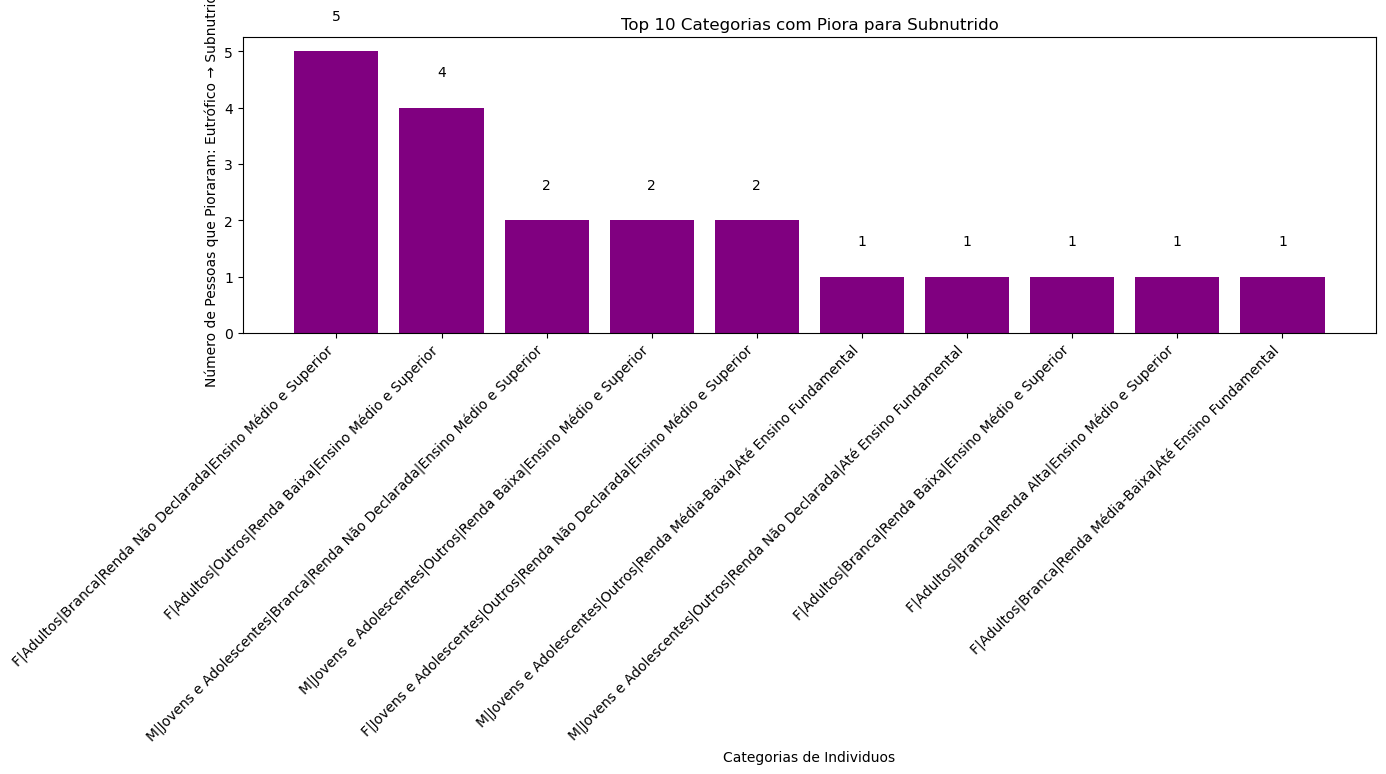

In [216]:
import pandas as pd
import matplotlib.pyplot as plt

# Classificação de IMC
def classificar_imc(imc):
    if imc < 18.5:
        return 'Subnutrido'
    elif imc < 25:
        return 'Eutrófico'
    elif imc < 30:
        return 'Sobrepeso'
    elif imc < 35:
        return 'Obesidade I'
    else:
        return 'Obesidade II'

 # Utilização do IMC PARA Comparar
df_final['Cat_2015'] = df_final['IMC_2015_contrafactual'].apply(classificar_imc)
df_final['Cat_2020'] = df_final['IMC_2020_contrafactual'].apply(classificar_imc)

## Colocar quais individuos pioraram
piorou_subnutrido = df_final[
    (df_final['Cat_2015'] == 'Eutrófico') & (df_final['Cat_2020'] == 'Subnutrido')
]

top_classe = piorou_subnutrido['Categorias'].value_counts().head(10)

# grafico
if not top_classe.empty:
    fig, ax = plt.subplots(figsize=(14,8))
    bars = ax.bar(top_classe.index, top_classe.values, color='purple')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(height),
                ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel('Número de Pessoas que Pioraram: Eutrófico → Subnutrido')
    ax.set_xlabel('Categorias de Individuos')
    ax.set_title('Top 10 Categorias com Piora para Subnutrido')
    ax.set_xticks(range(len(top_classe)))
    ax.set_xticklabels(top_classe.index, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


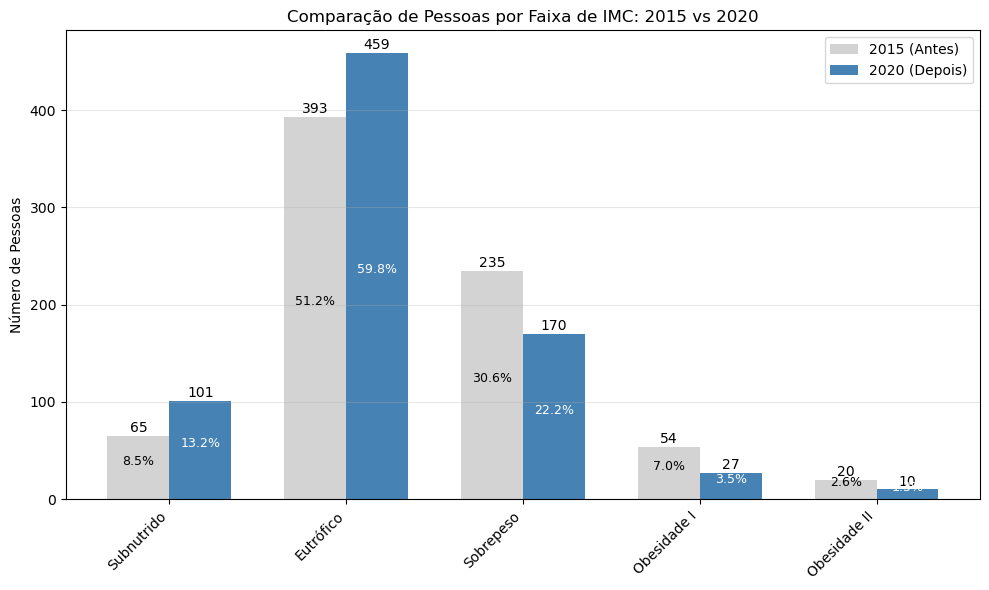

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def classificar_imc(imc):
    if imc < 18.5: 
        return "Subnutrido"
    elif imc < 25: 
        return "Eutrófico"
    elif imc < 30: 
        return "Sobrepeso"
    elif imc < 35: 
        return "Obesidade I"
    else: 
        return "Obesidade II"
# funcao para efetuar o compartivo
def analisar_imc_comparativo(df_final):
    #utilização da atulra
    altura = df_final['altura'].reset_index(drop=True)
    
    # IMC Antes e Depois dos contrafactuais
    imc_antes = df_final['Peso_2015_contrafactual'] / (altura**2)
    imc_depois = df_final['Peso_2020_contrafactual'] / (altura**2)
    
    faixas = ["Subnutrido","Eutrófico","Sobrepeso","Obesidade I","Obesidade II"]
    # criacao de uma dataframe compartivo
    df_comp = pd.DataFrame({
        'Antes': imc_antes.apply(classificar_imc).value_counts().reindex(faixas, fill_value=0),
        'Depois': imc_depois.apply(classificar_imc).value_counts().reindex(faixas, fill_value=0)
    })
    #calculo do total
    df_comp.loc['TOTAL'] = df_comp.sum()
    # calculo  associado ao porcentagem
    total_antes = df_comp['Antes'][:-1].sum()
    total_depois = df_comp['Depois'][:-1].sum()
    
    # Gráfico comparativo
    fig, ax = plt.subplots(figsize=(10,6))
    x = range(len(faixas))
    tamanho = 0.35
    
    barras_antes = ax.bar([i - tamanho/2 for i in x], df_comp['Antes'][:-1], tamanho, label='2015 (Antes)', color='lightgray')
    barras_depois = ax.bar([i + tamanho/2 for i in x], df_comp['Depois'][:-1], tamanho, label='2020 (Depois)', color='steelblue')
    
    # Números absolutos em cima e porcentagem no centro
    for barra, valor, total in zip(barras_antes, df_comp['Antes'][:-1], [total_antes]*len(faixas)):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5, f'{int(valor)}',
                ha='center', va='bottom', fontsize=10)
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height()/2, f'{valor/total*100:.1f}%',
                ha='center', va='bottom', fontsize=9, color='black')
    
    for barra, valor, total in zip(barras_depois, df_comp['Depois'][:-1], [total_depois]*len(faixas)):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5, f'{int(valor)}',
                ha='center', va='bottom', fontsize=10)
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height()/2, f'{valor/total*100:.1f}%',
                ha='center', va='bottom', fontsize=9, color='white')
    
    ax.set_xticks(x)
    ax.set_xticklabels(faixas, rotation=45, ha='right')
    ax.set_ylabel('Número de Pessoas')
    ax.set_title('Comparação de Pessoas por Faixa de IMC: 2015 vs 2020')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return imc_depois, df_comp

#chamada
imc_final, df_comparativo = analisar_imc_comparativo(df_final)


# Visualização e Mapa

In [167]:
!pip install geopandas matplotlib contextily folium  selenium pillow webdriver-manager overpy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [185]:
import pandas as pd
import warnings


warnings.simplefilter("ignore", UnicodeWarning)
# carregamento do banco de dados
df1 = pd.read_csv(r"C:/Users/vimed/Downloads/Dados_Geograficos_padrao.csv")
df2 = pd.read_stata(r"C:\Users\vimed\Downloads\Banco_ISA_AF_Ambiente_Vinicius (5).dta")

df =df1.merge(df2,right_on='id_original',left_on='id_original')


In [187]:
df_final=df_final.loc[:, ~df_final.columns.str.endswith(('_x', '_y'))]


In [ ]:


 #juncao em um unico dataframe
df_final = df_final.merge(df, right_on='id_original', left_on='id', how='inner')

Text(0.5, 1.0, 'Distribuição Simulação Contrafactual III(2020)-Politica de Equidade-Interseccionalidade - São Paulo')

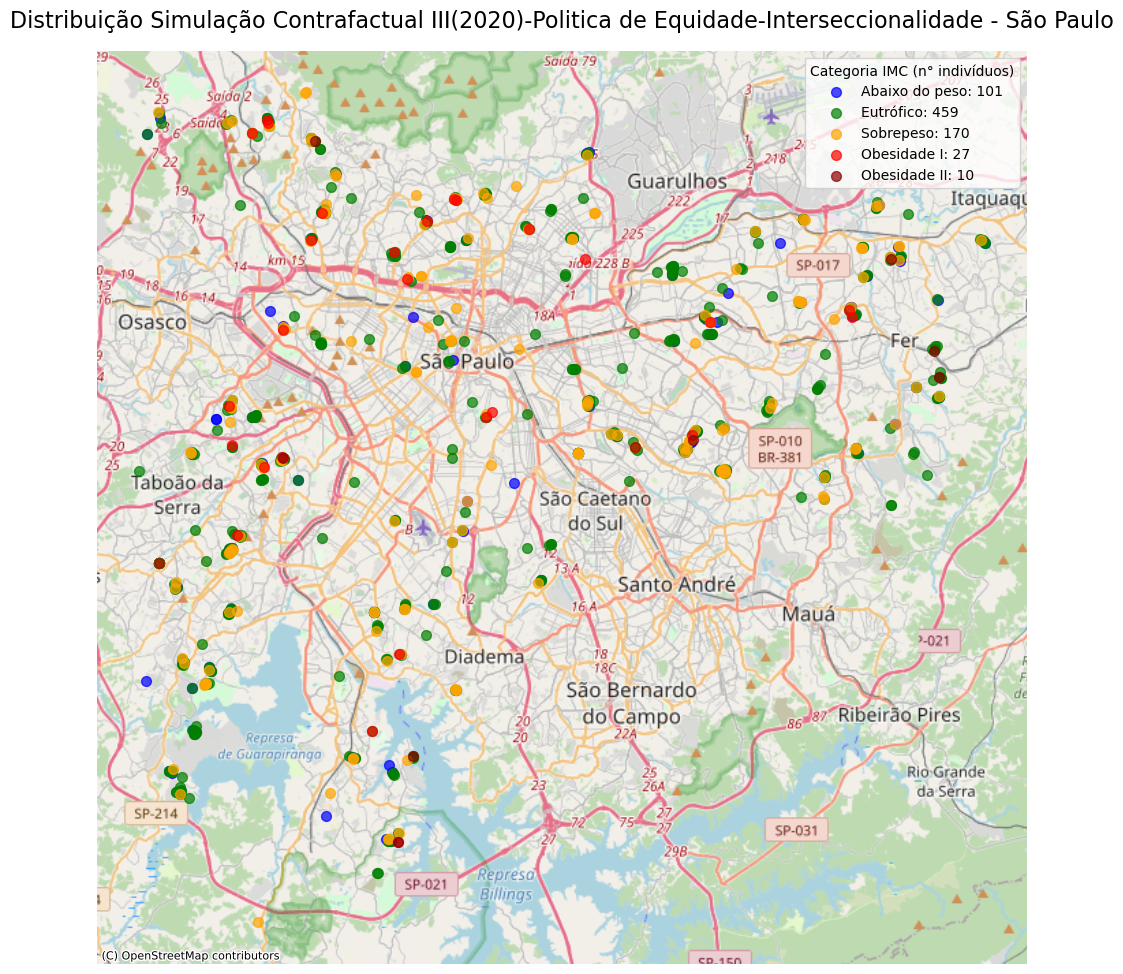

In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point
# preparação do datagrame
df_mapa = df_final.dropna(subset=["lat2020", "long2020", "IMC_2020_contrafactual"]).copy()



#classificação do IMC
def classificar_imc(imc):
    if imc < 18.5: return "Abaixo do peso"
    elif 18.5 <= imc < 25: return "Eutrófico"
    elif 25 <= imc < 30: return "Sobrepeso"
    elif 30 <= imc < 35: return "Obesidade I"
    else: return "Obesidade II"

#Aplicação da Funcao
df_mapa["categoria_imc"] = df_mapa["IMC_2020_contrafactual"].apply(classificar_imc)

#conversão do dataframe para geodataframe
gdf = gpd.GeoDataFrame(
    df_mapa,
    geometry=[Point(xy) for xy in zip(df_mapa["long2020"], df_mapa["lat2020"])],
    crs="EPSG:4326"
)
# conversao das geocoordenadas
gdf = gdf.to_crs(epsg=3857)

# paleta de cores por categorias
cores = {
    "Abaixo do peso": "blue",
    "Eutrófico": "green",
    "Sobrepeso": "orange",
    "Obesidade I": "red",
    "Obesidade II": "darkred"
}
# centralizacao do mapa
fig, ax = plt.subplots(figsize=(12,12))


legendas = []
#percorrer cada categoria
for categoria, cor in cores.items():
    subset = gdf[gdf["categoria_imc"] == categoria]
    if not subset.empty:
        subset.plot(ax=ax, markersize=50, color=cor, alpha=0.7)
        legendas.append(f"{categoria}: {len(subset)}")

#inserir o mapa no fundo
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()

#chamada da funcao
plt.legend(legendas, title="Categoria IMC (n° indivíduos)", loc="upper right", fontsize=10)
plt.title("Distribuição Simulação Contrafactual III(2020)-Politica de Equidade-Interseccionalidade - São Paulo", fontsize=16)



In [182]:
df_final=df_final.loc[:, ~df_final.columns.str.endswith(('_x', '_y'))]


In [208]:
warnings.simplefilter("ignore", UnicodeWarning)
# carregamento novamene do banco de dados
df = pd.read_csv(r"C:/Users/vimed/Downloads/Dados_Geograficos_padrao.csv")
# filtragem dos dados  de geolocalizacao

#consolidação do novodataframe
df_final = df_final.merge(df,right_on='id_original',left_on='id', how='inner')

In [210]:
df_final=df_final.loc[:, ~df_final.columns.str.endswith(('_x', '_y'))]


C:\Users\vimed\AppData\Local\Temp\ipykernel_84516\1434870011.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\vimed\AppData\Local\Temp\ipykernel_84516\1434870011.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\vimed\AppData\Local\Temp\ipykernel_84516\1434870011.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\vimed\AppData\Local\Temp\ipykernel_84516\1434870011.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `h

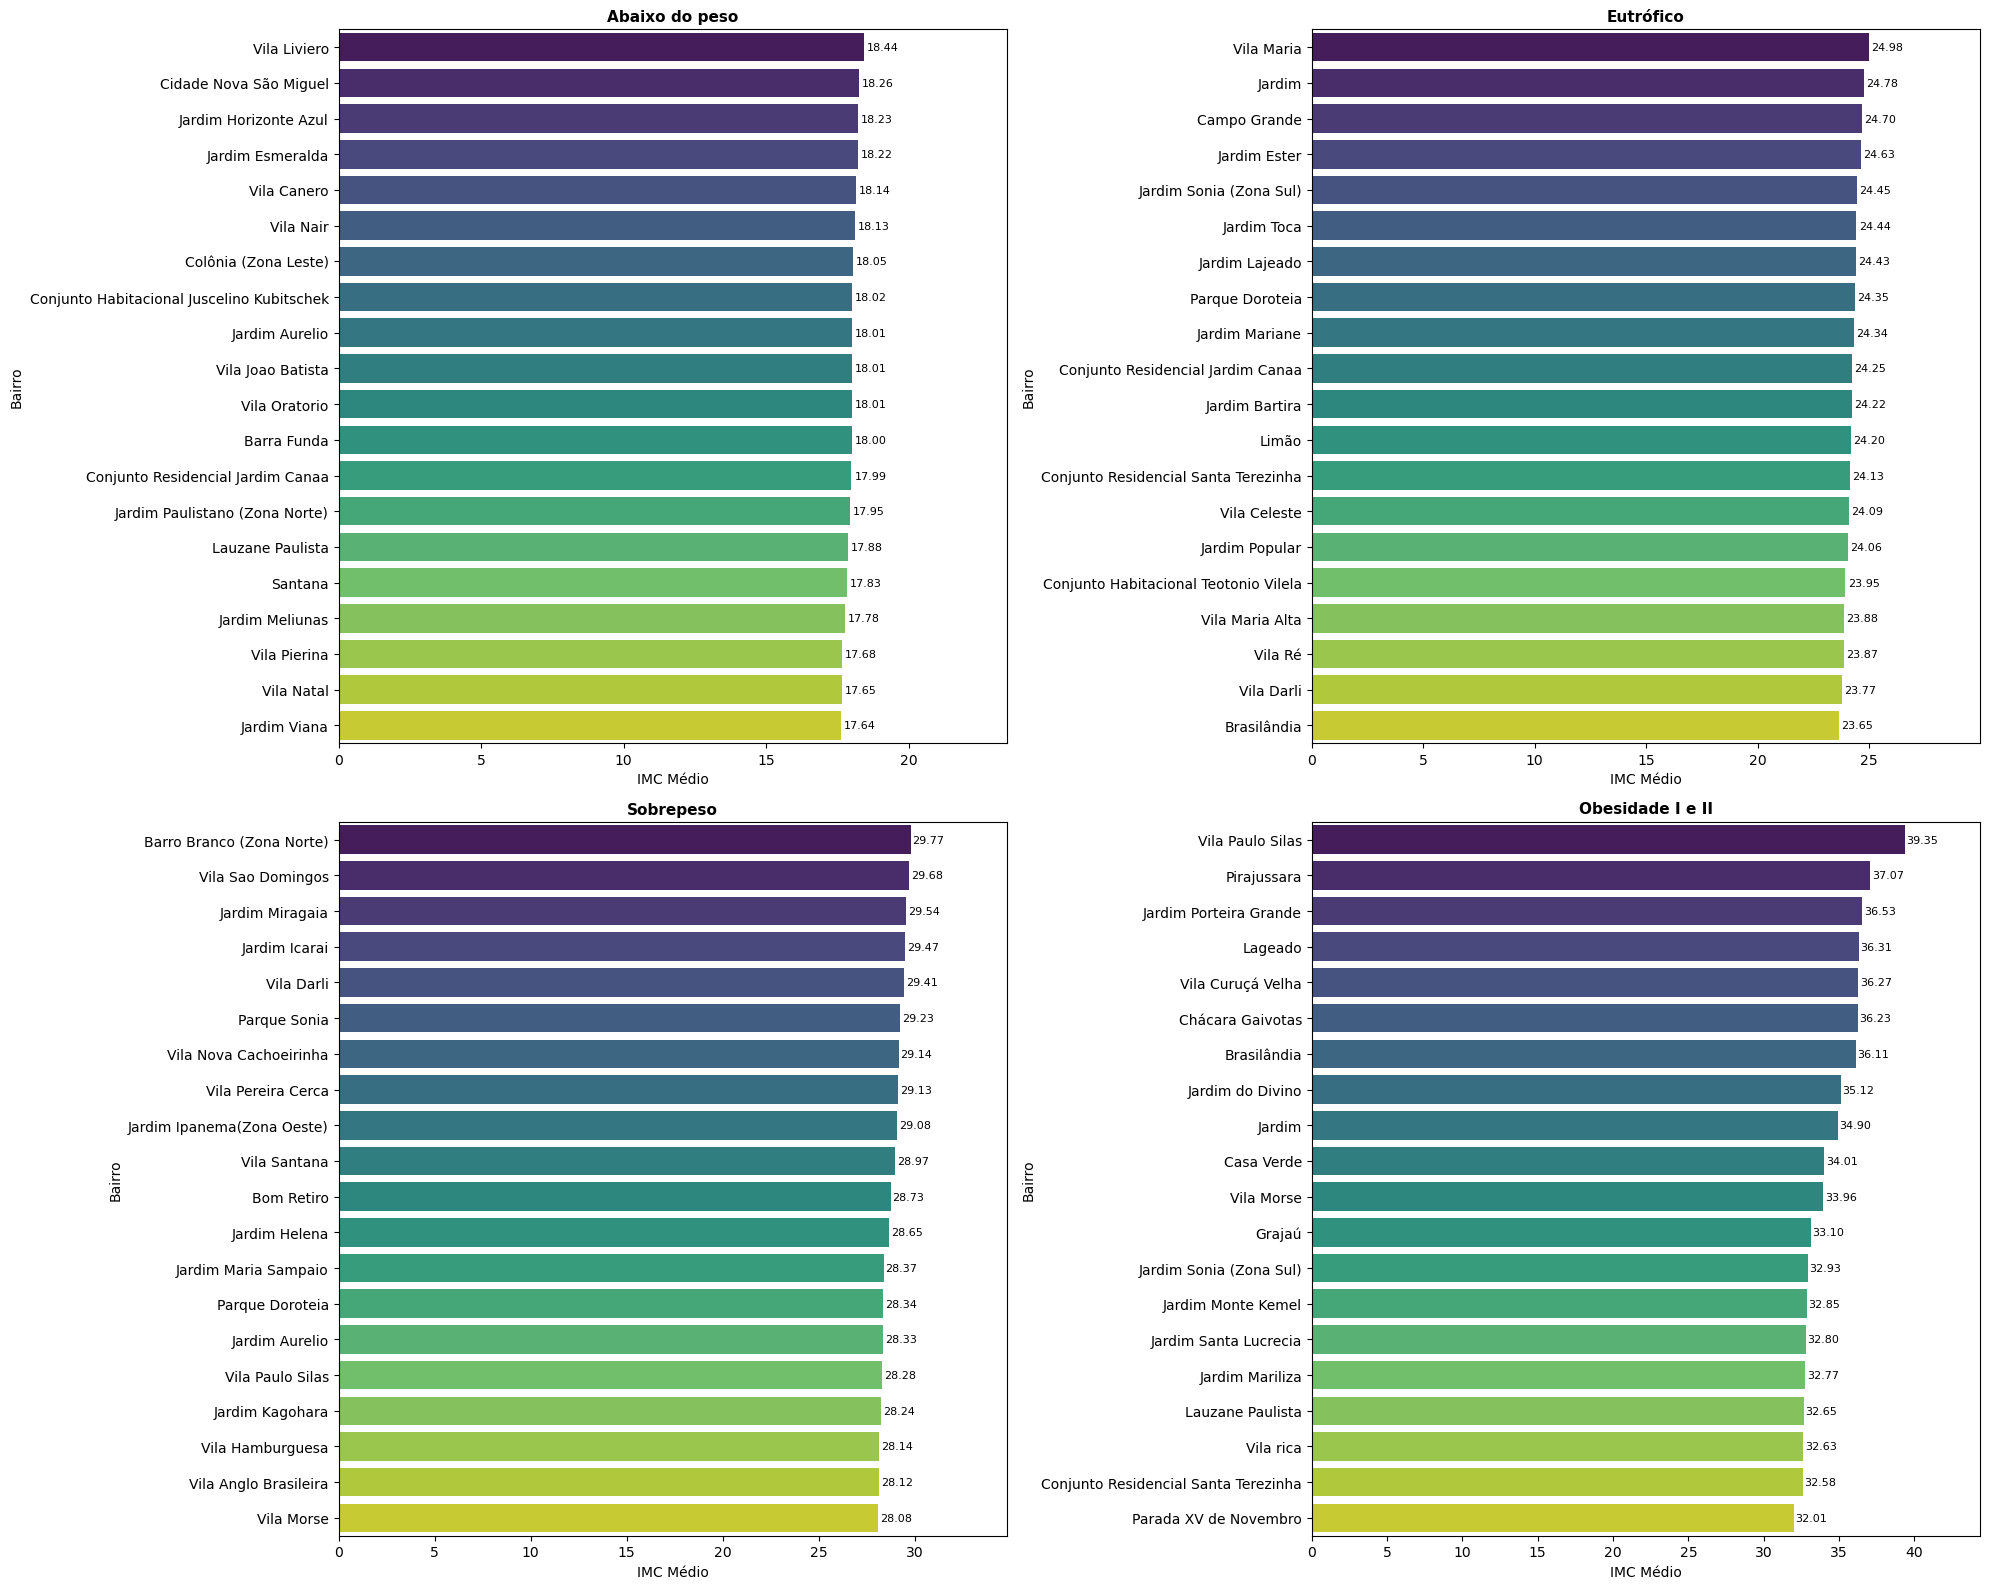

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

# remover linhas vazias
df_mapa = df_final.dropna(subset=["lat2020", "long2020", "IMC_2020_contrafactual"]).copy()

# funcao para classificar imc
def classificar_imc(imc):
    if imc < 18.5:
        return "Abaixo do peso"
    elif imc < 25:
        return "Eutrófico"
    elif imc < 30:
        return "Sobrepeso"
    elif imc < 35:
        return "Obesidade I"
    else:
        return "Obesidade II"
# aplicacao da classificacao no dataframe
df_mapa["categoria_imc"] = df_mapa["IMC_2020_contrafactual"].apply(classificar_imc)

#agregacacao  do obesidade i e  II em unica categoria
df_mapa["categoria_imc"] = df_mapa["categoria_imc"].replace(
    {"Obesidade I": "Obesidade I e II", "Obesidade II": "Obesidade I e II"}
)

# analise coordenada do geopandas via documentacao 
gdf = gpd.GeoDataFrame(
    df_mapa,
    geometry=[Point(xy) for xy in zip(df_mapa["long2020"], df_mapa["lat2020"])],
    crs="EPSG:4326"
).to_crs(epsg=3857)

#agregacacao por categoria e bairro e regiao cardinal
df_agg = (
    df_mapa
    .groupby(['categoria_imc', 'bairro', 'regiao_cardinal'], as_index=False)
    .agg(imc_medio=('IMC_2020_contrafactual', 'mean'))
)

# classificacao dos top 20  bairros  por cada  categoria
def plot_top20_ax(ax, df_agg, categoria_nome):
    top20 = (
        df_agg[df_agg['categoria_imc'] == categoria_nome]
        .sort_values(by='imc_medio', ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
# tratamento de erro 
    if top20.empty:
        ax.text(0.5, 0.5, 'Sem informacao', 
                ha='center', va='center', fontsize=12, color='gray')
        ax.set_title(categoria_nome, fontsize=11, fontweight='bold')
        ax.axis('off')
        return
# barras associadas
    sns.barplot(
        data=top20,
        y='bairro',
        x='imc_medio',
        palette="viridis", 
        ax=ax
    )

 
    for i, v in enumerate(top20['imc_medio']):
        ax.text(v + 0.1, i, f"{v:.2f}", color='black', va='center', fontsize=8)

    ax.set_title(categoria_nome, fontsize=11, fontweight='bold')
    ax.set_xlabel('IMC Médio')
    ax.set_ylabel('Bairro')
    ax.set_xlim(0, top20['imc_medio'].max() + 5)


fig, axs = plt.subplots(2, 2, figsize=(20, 16))
axs = axs.flatten()

categorias = ['Abaixo do peso', 'Eutrófico', 'Sobrepeso', 'Obesidade I e II']
# looping para criacao  do grafico via categoria
for ax, categoria_nome in zip(axs, categorias):
    plot_top20_ax(ax, df_agg, categoria_nome)
#chamada da funcao do grafico 
plt.tight_layout()
plt.show()
